<a href="https://colab.research.google.com/github/RCDS13/ANALISE-VARIAVEIS-ACIDENTES-SP/blob/main/analise_estatistica_transito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

!ls "/content/drive/MyDrive/PI_JP"
%load_ext rpy2.ipython

Mounted at /content/drive
base_prf_sp_tratada.rds  datatran2022.csv	    MALHA_RODOVIARIA.dbf
dataset_final.csv	 datatran2023.csv	    MALHA_RODOVIARIA.prj
dataset_final_SP.csv	 datatran2024.csv	    MALHA_RODOVIARIA.shp
dataset_junto.csv	 datatran2025.csv	    MALHA_RODOVIARIA.shx
dataset_sp.csv		 dicionario_variaveis.csv
datatran2021.csv	 dicionario_variaveis.docx


In [ ]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
!sudo rm -f /etc/apt/sources.list.d/ubuntugis*.list
!sudo rm -f /etc/apt/sources.list.d/deadsnakes*.list
!sudo rm -f /etc/apt/sources.list.d/r2u*.list
!sudo apt-get clean
!sudo apt-get update -qq
!sudo apt-get install -qq -y libudunits2-dev libgdal-dev libgeos-dev libproj-dev r-cran-sf

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 12.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package libcharls2:amd64.
(Reading database ... 118242 files and directories currently installed.)
Preparing to unpack .../00-libcharls2_2.3.4-1_amd64.deb ...
Unpacking libcharls2:amd64 (2.3.4-1) ...
Selecting previously unselected package libproj22:amd64.
Preparing to unpack .../01-libproj22_8.2.1-1_amd64.deb ...
Unpacking lib

In [ ]:
%%R
# Instala apenas os pacotes restantes
pacotes <- c("patchwork", "stringi", "lubridate")
instalados <- pacotes %in% rownames(installed.packages())
if(any(!instalados)) install.packages(pacotes[!instalados])

library(tidyverse)
library(sf)
library(patchwork)
library(stringi)
library(lubridate)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/patchwork_1.3.2.tar.gz'
Content type 'application/x-gzip' length 3322521 bytes (3.2 MB)
downloaded 3.2 MB


The downloaded source packages are in
	‘/tmp/RtmpKZROh9/downloaded_packages’
Linking to GEOS 3.12.1, GDAL 3.4.1, PROJ 8.2.1; sf_use_s2() is TRUE
Linked against: 3.12.1-CAPI-1.18.1 compiled against: 3.10.2-CAPI-1.16.0
It is probably a good idea to reinstall sf (and maybe lwgeom too)


In [ ]:
%%R

# TRATAMENTO, FILTRO SP E JUNÇÃO
caminho <- "/content/drive/MyDrive/PI_JP/"
arquivos <- list.files(path = caminho, pattern = "datatran.*\\.csv$", full.names = TRUE)

processar_dataset <- function(arquivo) {
  read_delim(arquivo, delim = ";", locale = locale(encoding = "Latin1"), show_col_types = FALSE) %>%
    rename(clima = any_of(c("condicao_metereologica", "clima")),
           feridos_graves = any_of(c("feridos_graves", "feridos_grave"))) %>%
    filter(uf == "SP") %>%
    mutate(across(everything(), as.character))
}

df_bruto <- arquivos %>% map_df(processar_dataset)
df_tratado <- df_bruto %>%

  mutate(across(everything(), ~na_if(.x, "(null)"))) %>%
  mutate(
    # Datas e Horas
    data_inversa = as.Date(data_inversa, format = "%Y-%m-%d"),


    across(c(km, latitude, longitude), ~as.numeric(str_replace_all(.x, ",", "."))),
    longitude = ifelse(longitude < -100, as.numeric(paste0(substr(as.character(longitude), 1, 3), ".", substr(as.character(longitude), 4, 15))), longitude),


    across(c(pessoas, mortos, feridos_leves, feridos_graves, ilesos, ignorados, feridos, veiculos), as.integer),


    dia_semana = factor(dia_semana, levels = c("segunda-feira", "terça-feira", "quarta-feira", "quinta-feira", "sexta-feira", "sábado", "domingo"), ordered = TRUE),
    causa_acidente = fct_lump_n(causa_acidente, n = 10, other_level = "Outras Causas"),
    municipio = fct_lump_n(municipio, n = 10, other_level = "Outros Municípios"),
    across(c(uf, tipo_acidente, classificacao_acidente, fase_dia, sentido_via, clima, tipo_pista, tracado_via, uso_solo), as.factor)
  )

write_rds(df_tratado, "/content/drive/MyDrive/PI_JP/base_prf_sp_tratada.rds")

glimpse(df_tratado)

Rows: 18,668
Columns: 30
$ id                     <chr> "331730", "332015", "332229", "332289", "332397…
$ data_inversa           <date> 2021-01-01, 2021-01-02, 2021-01-03, 2021-01-03…
$ dia_semana             <ord> sexta-feira, sábado, domingo, domingo, segunda-…
$ horario                <chr> "05:30:00", "10:20:00", "14:40:00", "18:10:00",…
$ uf                     <fct> SP, SP, SP, SP, SP, SP, SP, SP, SP, SP, SP, SP,…
$ br                     <chr> "116", "116", "153", "116", "381", "116", "116"…
$ km                     <dbl> 453.0, 362.6, 266.0, 230.5, 83.0, 362.2, 119.2,…
$ municipio              <fct> Outros Municípios, MIRACATU, Outros Municípios,…
$ causa_acidente         <fct> Reação tardia ou ineficiente do condutor, Outra…
$ tipo_acidente          <fct> Tombamento, Tombamento, Saída de leito carroçáv…
$ classificacao_acidente <fct> Com Vítimas Feridas, Com Vítimas Feridas, Com V…
$ fase_dia               <fct> Amanhecer, Pleno dia, Pleno dia, Anoitecer, Ple…
$ sentido_via  

In addition: Warning message:
There was 1 warning in `mutate()`.
ℹ In argument: `longitude = ifelse(...)`.
Caused by warning in `ifelse()`:
! NAs introduced by coercion 


In [ ]:
%%R -w 800 -h 1000 -r 120

df_tratado <- read_rds("/content/drive/MyDrive/PI_JP/base_prf_sp_tratada.rds")

# 1. Gráfico de Barras: Ranking das Causas (Frequência)
causas_acidente <- ggplot(df_tratado, aes(x = fct_rev(fct_infreq(causa_acidente)))) +
  geom_bar(fill = "steelblue") +
  coord_flip() + # Deita o gráfico para facilitar a leitura dos nomes
  theme_minimal() +
  labs(title = "1. Principais Causas de Acidentes (SP)", x = "Causa", y = "Qtd de Acidentes")

# 2. Gráfico de Colunas: Acidentes por Dia da Semana (Sazonalidade)
dia_semana <- ggplot(df_tratado, aes(x = dia_semana)) +
  geom_bar(fill = "darkorange") +
  theme_minimal() +
  labs(title = "2. Volume de Acidentes por Dia da Semana", x = "Dia da Semana", y = "Qtd de Acidentes")

# 3. Gráfico de Linha: Horários de Pico (Série Temporal Contínua)
horario_pico <- df_tratado %>%
  mutate(hora = as.integer(substr(horario, 1, 2))) %>% # Extrai a hora como inteiro
  filter(!is.na(hora)) %>% # Filtra NAs que podem surgir da conversão
  count(hora) %>% # Conta os acidentes por hora
  ggplot(aes(x = hora, y = n)) +
  geom_line(color = "darkred", linewidth = 1) +
  geom_point(color = "darkred", size = 2) +
  scale_x_continuous(breaks = 0:23) +
  theme_minimal() +
  labs(title = "3. Horários de Pico dos Acidentes", x = "Hora do Dia (0-23)", y = "Volume")

# 4. Boxplot: Quantidade de Pessoas Envolvidas por Fase do Dia (Dispersão e Outliers)
fase_dia <- ggplot(df_tratado, aes(x = fase_dia, y = pessoas)) +
  geom_boxplot(fill = "lightgreen", outlier.color = "red") +
  coord_cartesian(ylim = c(0, 10)) + # Corta o zoom para focar na maioria e não distorcer com casos extremos
  theme_minimal() +
  labs(title = "4. Distribuição de Envolvidos por Fase do Dia", x = "Fase do Dia", y = "Qtd de Pessoas")

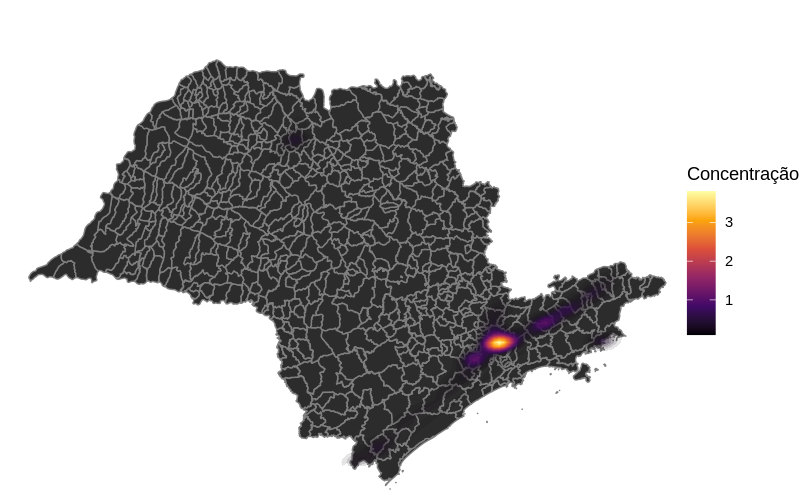

In [ ]:
%%R -w 800 -h 500 -r 120

# Install missing packages if not already installed
if (!requireNamespace("patchwork", quietly = TRUE)) {
  install.packages("patchwork", repos = "http://cran.us.r-project.org")
}
if (!requireNamespace("stringi", quietly = TRUE)) {
  install.packages("stringi", repos = "http://cran.us.r-project.org")
}

library(tidyverse)
library(sf)
library(patchwork) # Pacote para juntar os gráficos
library(stringi)   # Para tratar os acentos dos nomes das cidades

# 1. Carregar a base tratada
df <- read_rds("/content/drive/MyDrive/PI_JP/base_prf_sp_tratada.rds")

# Filtro do mapa (Tira lixo de GPS)
df_mapa <- df %>%
  filter(
    !is.na(latitude) & !is.na(longitude),
    latitude >= -25.5 & latitude <= -19.0,
    longitude >= -53.5 & longitude <= -44.0
  )

# 2. Descarregar malha municipal do IBGE
url_ibge <- "https://servicodados.ibge.gov.br/api/v3/malhas/estados/35?formato=application/vnd.geo+json&intrarregiao=municipio"
mapa_sp <- read_sf(url_ibge)

# ==========================================
# PARTE A: CRIANDO O MAPA (g_mapa)
# ==========================================
g_mapa <- ggplot() +
  geom_sf(data = mapa_sp, fill = "#2c2c2c", color = "gray50", linewidth = 0.4) +

  stat_density_2d(data = df_mapa,
                  aes(x = longitude, y = latitude,
                      fill = after_stat(level), alpha = after_stat(level)),
                  geom = "polygon", bins = 40) +

  scale_fill_viridis_c(option = "inferno", name = "Concentração") +
  scale_alpha(guide = "none") +


  # Zoom ajustado
  coord_sf(xlim = c(-53.5, -44.0), ylim = c(-25.5, -19.0), expand = FALSE) +

  theme_void() +

  theme(legend.position = "right",
        plot.title = element_text(hjust = 0.5, face = "bold", size = 14, margin = margin(b = 5)),
        plot.subtitle = element_text(hjust = 0.5, size = 10, margin = margin(b = 15)))
  print(g_mapa)

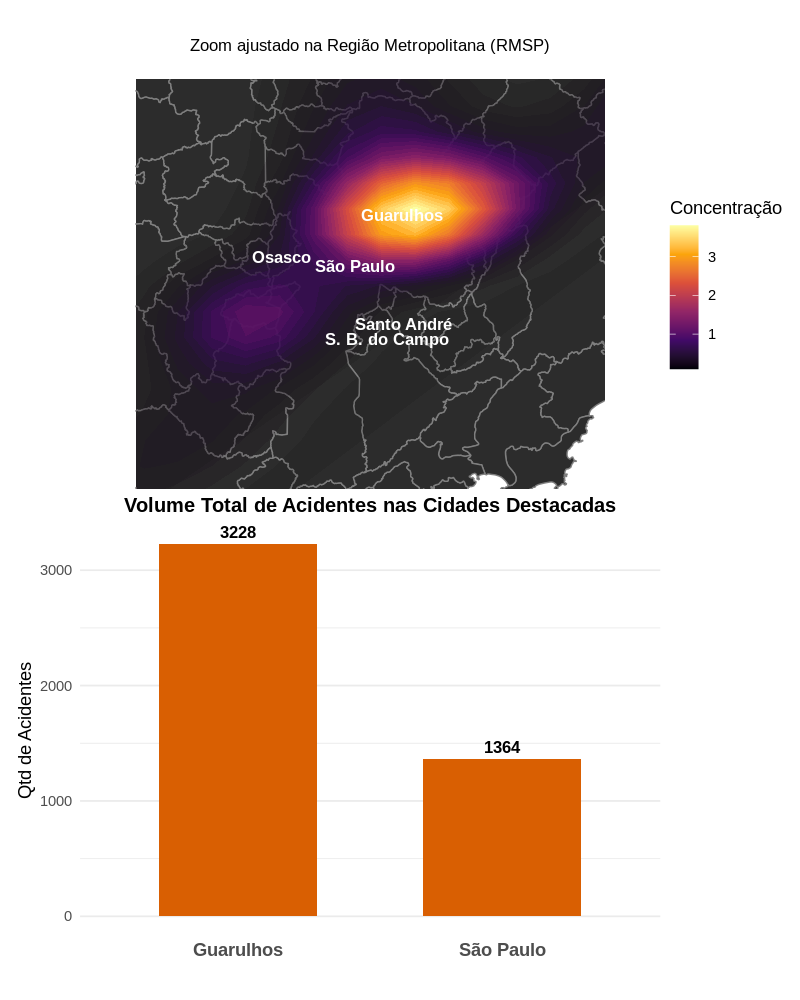

In [ ]:
%%R -w 800 -h 1000 -r 120

# Install missing packages if not already installed
if (!requireNamespace("patchwork", quietly = TRUE)) {
  install.packages("patchwork", repos = "http://cran.us.r-project.org")
}
if (!requireNamespace("stringi", quietly = TRUE)) {
  install.packages("stringi", repos = "http://cran.us.r-project.org")
}

library(tidyverse)
library(sf)
library(patchwork) # Pacote para juntar os gráficos
library(stringi)   # Para tratar os acentos dos nomes das cidades

# 1. Carregar a base tratada
df <- read_rds("/content/drive/MyDrive/PI_JP/base_prf_sp_tratada.rds")

# Filtro do mapa (Tira lixo de GPS)
df_mapa <- df %>%
  filter(
    !is.na(latitude) & !is.na(longitude),
    latitude >= -25.5 & latitude <= -19.0,
    longitude >= -53.5 & longitude <= -44.0
  )

# 2. Descarregar malha municipal do IBGE
url_ibge <- "https://servicodados.ibge.gov.br/api/v3/malhas/estados/35?formato=application/vnd.geo+json&intrarregiao=municipio"
mapa_sp <- read_sf(url_ibge)

# 3. Cidades da Grande São Paulo para referência
cidades_rmsp <- data.frame(
  nome = c("São Paulo", "Guarulhos", "Osasco", "S. B. do Campo", "Santo André"),
  lon = c(-46.633, -46.533, -46.790, -46.565, -46.528),
  lat = c(-23.550, -23.450, -23.532, -23.693, -23.663)
)

# ==========================================
# PARTE A: CRIANDO O MAPA (g_mapa)
# ==========================================
g_mapa <- ggplot() +
  geom_sf(data = mapa_sp, fill = "#2c2c2c", color = "gray50", linewidth = 0.4) +

  stat_density_2d(data = df_mapa,
                  aes(x = longitude, y = latitude,
                      fill = after_stat(level), alpha = after_stat(level)),
                  geom = "polygon", bins = 40) +

  scale_fill_viridis_c(option = "inferno", name = "Concentração") +
  scale_alpha(guide = "none") +

  geom_text(data = cidades_rmsp, aes(x = lon, y = lat, label = nome),
            color = "white", size = 3.5, fontface = "bold", nudge_y = -0.015) +

  # Zoom ajustado
  coord_sf(xlim = c(-47.10, -46.10), ylim = c(-24.00, -23.20), expand = FALSE) +

  theme_void() +
  labs(title = "",
       subtitle = "Zoom ajustado na Região Metropolitana (RMSP)") +

  theme(legend.position = "right",
        plot.title = element_text(hjust = 0.5, face = "bold", size = 14, margin = margin(b = 5)),
        plot.subtitle = element_text(hjust = 0.5, size = 10, margin = margin(b = 15)))

# ==========================================
# PARTE B: CRIANDO O GRÁFICO DE BARRAS (g_barras)
# ==========================================
# Nomes exatos sem acento para buscar na base da PRF
municipios_alvo <- c("SAO PAULO", "GUARULHOS", "OSASCO", "SAO BERNARDO DO CAMPO", "SANTO ANDRE")

df_barras <- df %>%
  # Remove acentos e joga para maiúsculo para não ter erro de digitação da PRF
  mutate(muni_clean = stri_trans_general(str_to_upper(municipio), "Latin-ASCII")) %>%
  filter(muni_clean %in% municipios_alvo) %>%
  count(muni_clean) %>%
  # Arruma os nomes para ficar bonito na legenda do gráfico
  mutate(Nome = case_when(
    muni_clean == "SAO PAULO" ~ "São Paulo",
    muni_clean == "GUARULHOS" ~ "Guarulhos",
    muni_clean == "OSASCO" ~ "Osasco",
    muni_clean == "SAO BERNARDO DO CAMPO" ~ "S. B. do Campo",
    muni_clean == "SANTO ANDRE" ~ "Santo André"
  ))

g_barras <- ggplot(df_barras, aes(x = reorder(Nome, -n), y = n)) +
  geom_col(fill = "#d95f02", width = 0.6) +
  geom_text(aes(label = n), vjust = -0.5, size = 3.5, fontface = "bold") +
  theme_minimal() +
  labs(title = "Volume Total de Acidentes nas Cidades Destacadas",
       x = "", y = "Qtd de Acidentes") +
  theme(plot.title = element_text(hjust = 0.5, face = "bold", size = 12),
        axis.text.x = element_text(size = 11, face = "bold"),
        panel.grid.major.x = element_blank())

painel_final <- g_mapa / g_barras + plot_layout(heights = c(2, 2))

# Exibe a imagem unificada
print(painel_final)

A rodovia mais fatal em SP no período é a BR- 116  com  662  mortes registradas.


In addition: Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


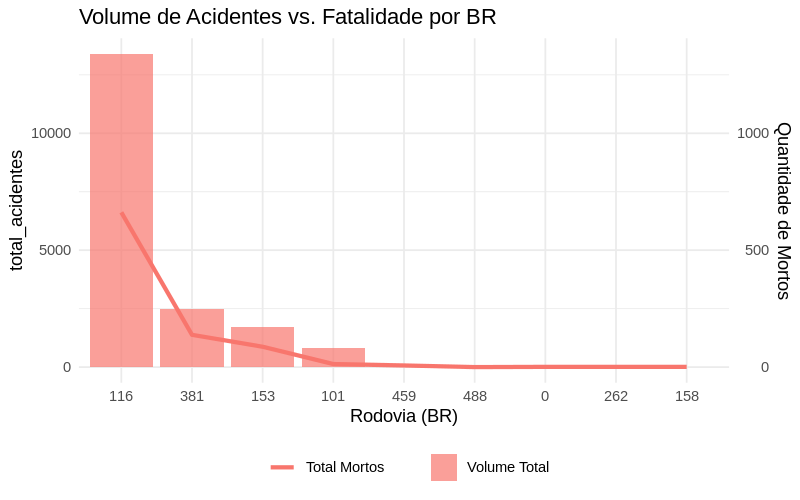

In [ ]:
%%R -w 800 -h 500 -r 120

# Ensure df_tratado (now named df) is loaded for this session
df <- read_rds("/content/drive/MyDrive/PI_JP/base_prf_sp_tratada.rds")

# Filter map data (df_mapa) from df
df_mapa <- df %>%
  filter(
    !is.na(latitude) & !is.na(longitude),
    latitude >= -25.5 & latitude <= -19.0,
    longitude >= -53.5 & longitude <= -44.0
  )

# Download municipal mesh from IBGE (mapa_sp)
url_ibge <- "https://servicodados.ibge.gov.br/api/v3/malhas/estados/35?formato=application/vnd.geo+json&intrarregiao=municipio"
mapa_sp <- read_sf(url_ibge)

# 1. Preparação dos dados por Rodovia
# Precisamos saber quantos dias existem no seu dataset para calcular a média
total_dias <- as.numeric(max(df$data_inversa) - min(df$data_inversa))

df_rodovias <- df %>%
  filter(!is.na(br)) %>%
  group_by(br) %>%
  summarise(
    total_acidentes = n(),
    total_mortos = sum(mortos, na.rm = TRUE),
    media_acidentes_dia = total_acidentes / total_dias,
    letalidade_media = total_mortos / total_acidentes
  ) %>%
  arrange(desc(total_mortos))

# 2. Identificando a mais fatal
mais_fatal <- df_rodovias[1, ]
cat("A rodovia mais fatal em SP no período é a BR-", mais_fatal$br,
    " com ", mais_fatal$total_mortos, " mortes registradas.\n")

# 3. Gráfico de Comparação: Volume vs Fatalidade
g_comparativo <- ggplot(df_rodovias, aes(x = reorder(br, -total_acidentes))) +
  geom_col(aes(y = total_acidentes, fill = "Volume Total"), alpha = 0.7) +
  geom_line(aes(y = total_mortos * 10, group = 1, color = "Total Mortos"), size = 1.2) +
  scale_y_continuous(sec.axis = sec_axis(~./10, name = "Quantidade de Mortos")) +
  theme_minimal() +
  labs(title = "Volume de Acidentes vs. Fatalidade por BR", x = "Rodovia (BR)", fill = "", color = "") +
  theme(legend.position = "bottom")

# 4. Mapa Geográfico com classificação de risco
# Usando o mapa_sp que você já baixou da API do IBGE
ggplot() +
  geom_sf(data = mapa_sp, fill = "#2c2c2c", color = "gray30", linewidth = 0.2) +
  # Plotando os pontos dos acidentes coloridos pela Rodovia
  geom_point(data = df_mapa, aes(x = longitude, y = latitude, color = br),
             alpha = 0.4, size = 0.5) +
  scale_color_viridis_d(option = "turbo", name = "Rodovia") +
  coord_sf(xlim = c(-53.5, -44.0), ylim = c(-25.5, -19.0), expand = FALSE) +
  theme_void() +
  labs(title = "Distribuição das Rodovias Federais em SP",
       subtitle = "Cada cor representa uma BR diferente cortando o estado") +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"))

# Exibe o gráfico comparativo
print(g_comparativo)

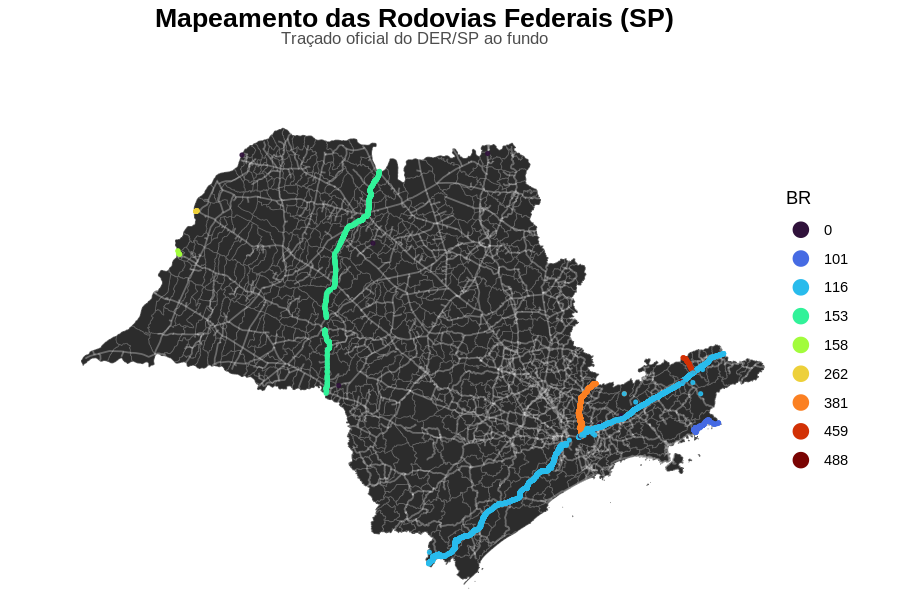

In [ ]:
%%R -w 900 -h 600 -r 120

library(tidyverse)
library(sf)

# 1. Carrega os Acidentes
df_mapa <- df %>%
  filter(!is.na(latitude) & !is.na(longitude) & !is.na(br)) %>%
  mutate(br = as.character(br))

# 2. Carrega o fundo de SP (IBGE)
url_ibge <- "https://servicodados.ibge.gov.br/api/v3/malhas/estados/35?formato=application/vnd.geo+json&intrarregiao=municipio"
mapa_sp <- read_sf(url_ibge)

# 3. Carrega o Shapefile Oficial do DER/SP que acabou de descarregar
# Confirme se o caminho corresponde ao local exato no seu Drive
rodovias_sp <- read_sf("/content/drive/MyDrive/PI_JP/MALHA_RODOVIARIA.shp")

# 4. Plota o mapa definitivo
ggplot() +
  # Camada 1: Municípios de SP
  geom_sf(data = mapa_sp, fill = "#2c2c2c", color = "gray40", linewidth = 0.2) +

  # Camada 2: Traçado real das rodovias (O ficheiro .shp)
  geom_sf(data = rodovias_sp, color = "white", linewidth = 0.5, alpha = 0.3) +

  # Camada 3: Acidentes sobrepostos
  geom_point(data = df_mapa, aes(x = longitude, y = latitude, color = br),
             alpha = 0.9, size = 0.8) +

  scale_color_viridis_d(option = "turbo", name = "BR") +
  coord_sf(xlim = c(-53.5, -44.0), ylim = c(-25.5, -19.0), expand = FALSE) +

  theme_void() +
  labs(title = "Mapeamento das Rodovias Federais (SP)",
       subtitle = "Traçado oficial do DER/SP ao fundo") +
  guides(color = guide_legend(override.aes = list(size = 4, alpha = 1))) +
  theme(
    legend.position = "right",
    plot.title = element_text(hjust = 0.5, face = "bold", size = 16),
    plot.subtitle = element_text(hjust = 0.5, size = 10, color = "gray30", margin = margin(b = 10)),
    plot.background = element_rect(fill = "white", color = NA)
  )

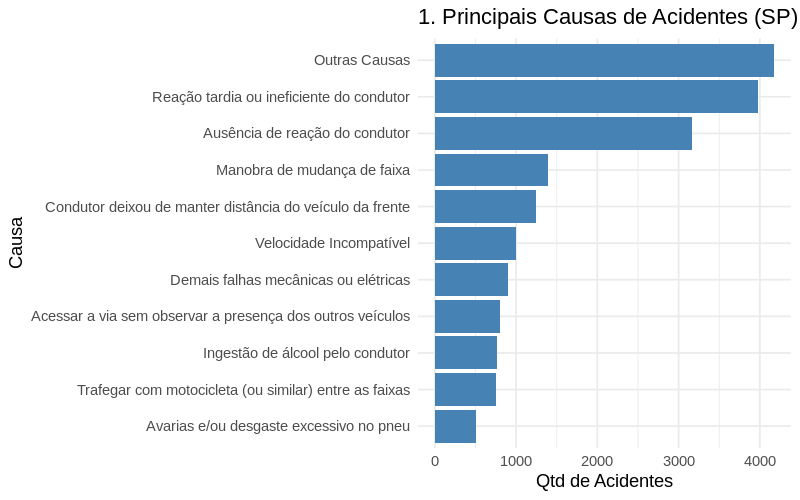

In [ ]:
%%R -w 800 -h 500 -r 120

print(causas_acidente)

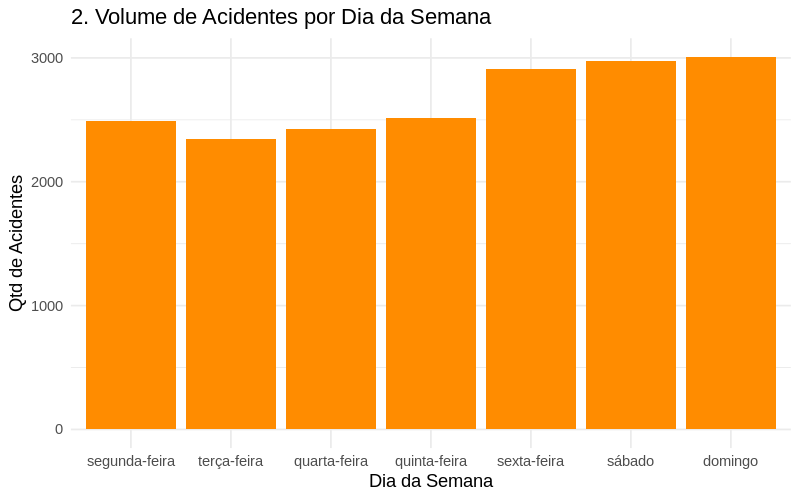

In [ ]:
%%R -w 800 -h 500 -r 120

print(dia_semana)

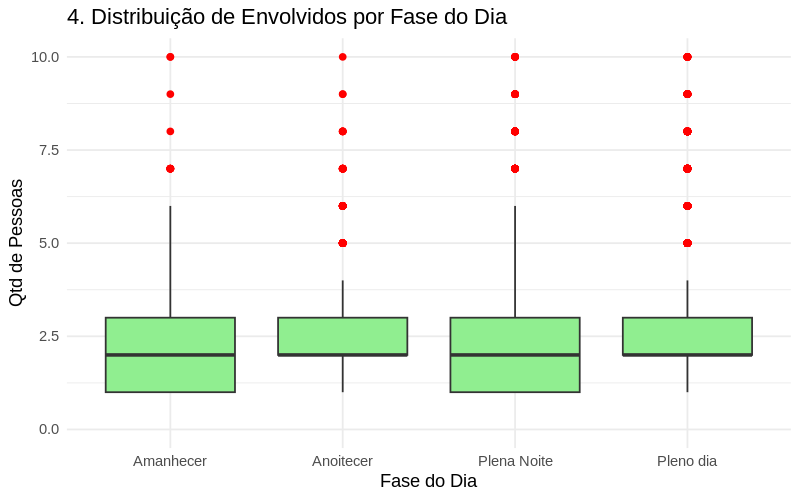

In [ ]:
%%R -w 800 -h 500 -r 120

print(fase_dia)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘plyr’, ‘reshape2’

trying URL 'https://cloud.r-project.org/src/contrib/plyr_1.8.9.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/reshape2_1.4.5.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/ggcorrplot_0.1.4.1.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpKZROh9/downloaded_packages’
In addition: Warning message:
`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggcorrplot package.
  Please report the issue at <https://github.com/kassambara/ggcorrplot/issues>.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


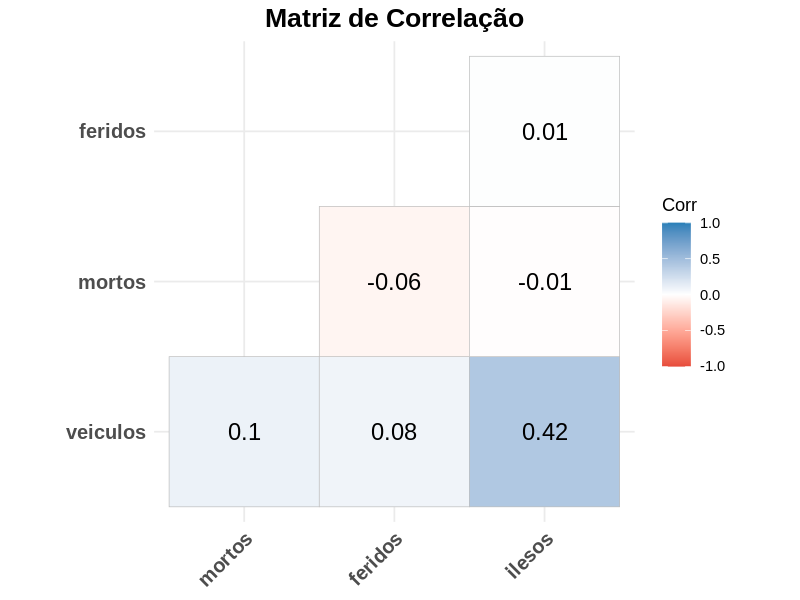

In [ ]:
%%R -w 800 -h 600 -r 120

library(tidyverse)
# Install missing packages if not already installed
if (!requireNamespace("ggcorrplot", quietly = TRUE)) {
  install.packages("ggcorrplot", repos = "https://cloud.r-project.org")
}
library(ggcorrplot)

# Ensure df is loaded
df <- read_rds("/content/drive/MyDrive/PI_JP/base_prf_sp_tratada.rds")

# 1. Filtra apenas as colunas numéricas de interesse (excluindo coordenadas/IDs)
df_numerico <- df %>%
  select(veiculos, mortos, feridos, ilesos) %>%
  drop_na() # Remove linhas com valores vazios para não dar erro no cálculo

# 2. Calcula a matriz matemática de correlação (Pearson)
matriz_cor <- cor(df_numerico)

# 3. Plota o gráfico
ggcorrplot(matriz_cor,
           method = "square",
           type = "lower",      # Mostra só a metade de baixo (pois é simétrico)
           lab = TRUE,          # Mostra os números exatos da correlação
           lab_size = 5,
           colors = c("#e74c3c", "white", "#2980b9"), # Vermelho (negativa), Branco (neutra), Azul (positiva)
           title = "Matriz de Correlação",
           ggtheme = theme_minimal()) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5, size = 16),
    axis.text = element_text(face = "bold", size = 12)
  )

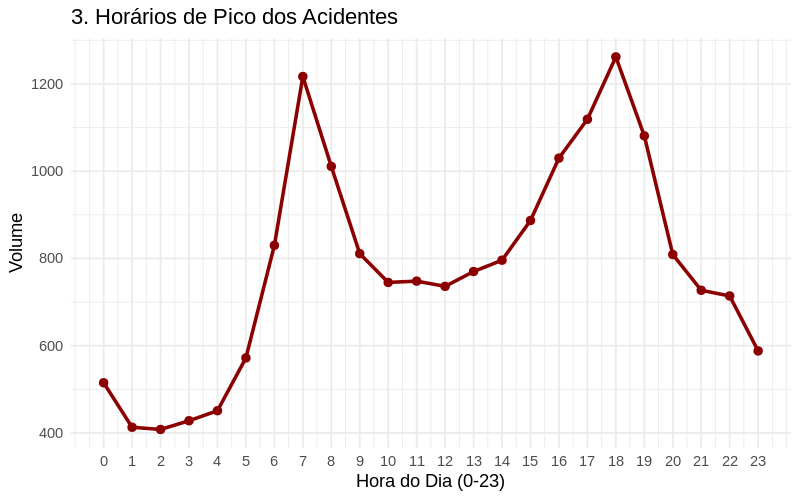

In [ ]:
%%R -w 800 -h 500 -r 120

print(horario_pico)

(Intercept)        hora 
  579.96333    17.20609 


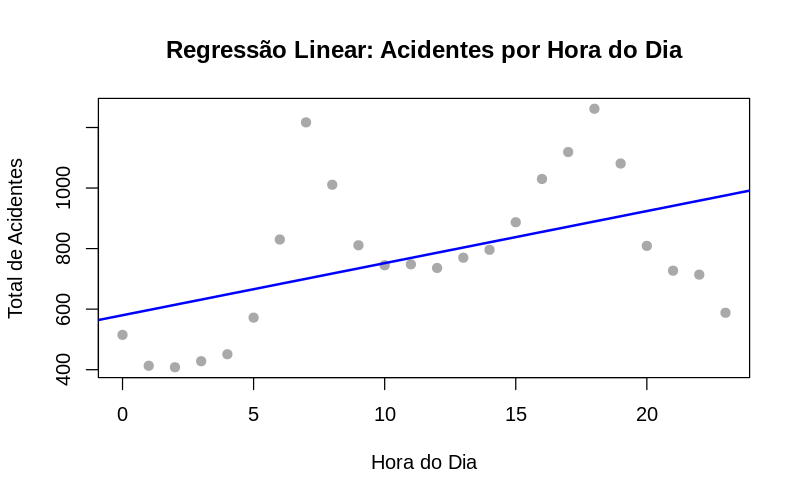

In [ ]:
%%R -w 800 -h 500 -r 120

library(tidyverse) # Garante que o tidyverse esteja carregado para %>% e read_rds

# Ensure df_tratado is loaded
df_tratado <- read_rds("/content/drive/MyDrive/PI_JP/base_prf_sp_tratada.rds")

# Prepare data for correlation: accidents count per hour
df_hora_dia <- df_tratado %>%
  mutate(hora = as.integer(substr(horario, 1, 2))) %>%
  filter(!is.na(hora)) %>%
  count(hora, name = "total_acidentes")

# Define x and y for the model
x_data <- df_hora_dia$hora
y_data <- df_hora_dia$total_acidentes

modelo <- lm(
  formula = total_acidentes ~ hora,
  data = df_hora_dia,
  na.action = na.omit
)

# Plot the data and the regression line
# Corrected plot to have 'hora' on x-axis and 'total_acidentes' on y-axis
plot(x_data, y_data, pch = 19, col = "darkgray",
     xlab = "Hora do Dia", ylab = "Total de Acidentes",
     main = "Regressão Linear: Acidentes por Hora do Dia")
abline(modelo, col = "blue", lwd = 2)

coef(modelo)

In [ ]:
%%R

if (!requireNamespace("FNN", quietly = TRUE)) {
  install.packages("FNN", repos = "https://cloud.r-project.org")
}
library(FNN)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/FNN_1.1.4.1.tar.gz'
Content type 'application/x-gzip' length 78809 bytes (76 KB)
downloaded 76 KB


The downloaded source packages are in
	‘/tmp/RtmpKZROh9/downloaded_packages’


In [ ]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


## 📊 Análise de Impacto: Qual variável mais influencia a gravidade dos acidentes?

Utilizamos **Regressão Linear Múltipla** com **`drop1()` (F-test)** para medir a contribuição de cada variável.  
Diferente de uma correlação simples, este método:  
- Controla o efeito de **todas as variáveis simultaneamente**  
- Permite comparar variáveis **numéricas e categóricas** na mesma escala  
- Isola a contribuição **única** de cada fator — sem instalar pacotes extras  

**Variável alvo:** `mortos` por acidente (gravidade do acidente)

R² Ajustado: 0.0472 
F-statistic do modelo: 4.57 

=== RANKING DE IMPACTO (F-statistic) === 
           label_var     F_stat      p_valor          significativa
1     Nº de Veículos 234.147908 1.563792e-52 Significativa (p<0,05)
2        Fase do Dia  51.086929 7.133449e-33 Significativa (p<0,05)
3  Causa do Acidente  39.132607 4.719785e-77 Significativa (p<0,05)
4        Hora do Dia   7.127209 7.598947e-03 Significativa (p<0,05)
5      Fim de Semana   3.533999 6.013839e-02      Não significativa
6 Condição Climática   2.664341 4.352160e-03 Significativa (p<0,05)
7     Traçado da Via   1.488409 2.232695e-06 Significativa (p<0,05)
8      Pista Simples   1.450247 2.285037e-01      Não significativa
9         Zona Rural         NA           NA                   <NA>



(`geom_segment()`). 

(`geom_point()`). 

(`geom_text()`). 



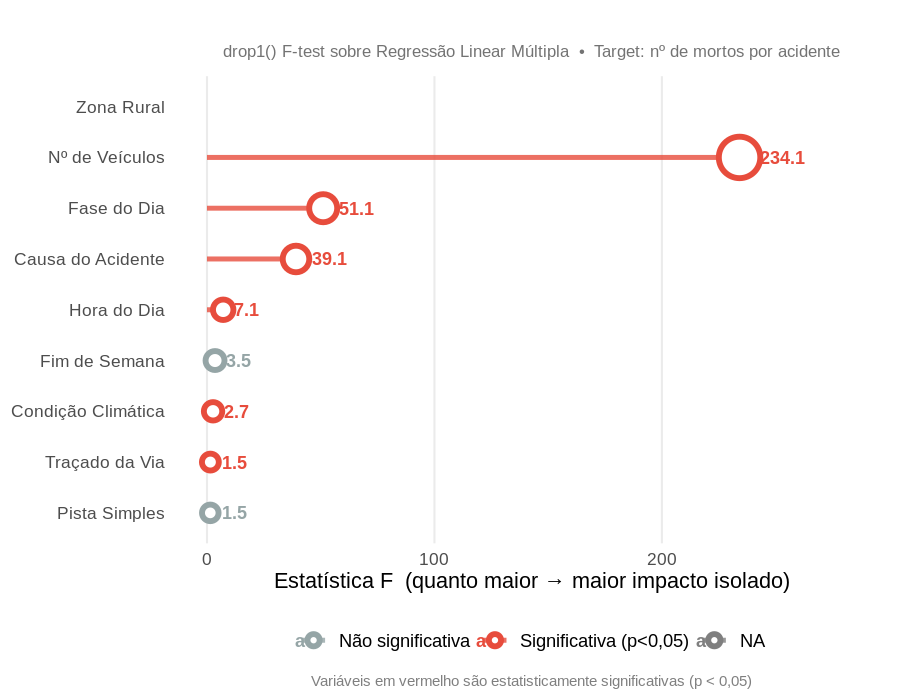

In [ ]:
%%R -w 900 -h 700 -r 120

library(tidyverse)

# ================================================================
# ANÁLISE DE IMPACTO: REGRESSÃO MÚLTIPLA + drop1() F-test (base R)
# ================================================================

df <- read_rds("/content/drive/MyDrive/PI_JP/base_prf_sp_tratada.rds")

# 1. PREPARAÇÃO
df_modelo <- df %>%
  mutate(
    hora          = as.integer(substr(horario, 1, 2)),
    fim_semana    = as.integer(dia_semana %in% c("sábado", "domingo")),
    pista_simples = as.integer(tipo_pista == "Simples"),
    uso_rural     = as.integer(uso_solo   == "Rural")
  ) %>%
  select(mortos, veiculos, hora, fim_semana, pista_simples, uso_rural,
         fase_dia, clima, tracado_via, causa_acidente) %>%
  drop_na()

# 2. REGRESSÃO LINEAR MÚLTIPLA
modelo <- lm(
  mortos ~ veiculos + hora + fim_semana + pista_simples + uso_rural +
           fase_dia + clima + tracado_via + causa_acidente,
  data = df_modelo
)

resumo <- summary(modelo)
cat("R² Ajustado:", round(resumo$adj.r.squared, 4), "\n")
cat("F-statistic do modelo:", round(resumo$fstatistic[1], 2), "\n\n")

# 3. drop1() — F-TEST PARA CADA VARIÁVEL
tab_drop <- drop1(modelo, test = "F")

df_imp <- tab_drop %>%
  as.data.frame() %>%
  rownames_to_column("variavel") %>%
  filter(variavel != "<none>") %>%
  rename(F_stat = `F value`, p_valor = `Pr(>F)`) %>%
  mutate(
    significativa = ifelse(p_valor < 0.05, "Significativa (p<0,05)", "Não significativa"),
    label_var = recode(variavel,
      veiculos       = "Nº de Veículos",
      hora           = "Hora do Dia",
      fim_semana     = "Fim de Semana",
      pista_simples  = "Pista Simples",
      uso_rural      = "Zona Rural",
      fase_dia       = "Fase do Dia",
      clima          = "Condição Climática",
      tracado_via    = "Traçado da Via",
      causa_acidente = "Causa do Acidente"
    )
  ) %>%
  arrange(desc(F_stat))

cat("=== RANKING DE IMPACTO (F-statistic) ===", "\n")
print(df_imp %>% select(label_var, F_stat, p_valor, significativa))

# 4. GRÁFICO LOLLIPOP
ggplot(df_imp, aes(x = reorder(label_var, F_stat), y = F_stat, color = significativa)) +
  geom_segment(aes(xend = reorder(label_var, F_stat), yend = 0),
               linewidth = 1.4, alpha = 0.8) +
  geom_point(aes(size = F_stat), shape = 21, fill = "white", stroke = 2.5) +
  geom_text(aes(label = formatC(F_stat, format = "f", digits = 1)),
            hjust = -0.45, size = 3.8, fontface = "bold") +
  scale_color_manual(
    values = c("Significativa (p<0,05)" = "#e74c3c",
               "Não significativa"      = "#95a5a6"),
    name = NULL
  ) +
  scale_size_continuous(range = c(3, 10), guide = "none") +
  coord_flip() +
  expand_limits(y = max(df_imp$F_stat, na.rm = TRUE) * 1.22) +
  theme_minimal(base_size = 13) +
  labs(
    title    = "",
    subtitle = "drop1() F-test sobre Regressão Linear Múltipla  •  Target: nº de mortos por acidente",
    x        = NULL,
    y        = "Estatística F  (quanto maior → maior impacto isolado)",
    caption  = "Variáveis em vermelho são estatisticamente significativas (p < 0,05)"
  ) +
  theme(
    plot.title         = element_text(face = "bold", size = 15, hjust = 0.5),
    plot.subtitle      = element_text(size = 10, hjust = 0.5, color = "gray45",
                                       margin = margin(b = 10)),
    plot.caption       = element_text(size = 9, color = "gray50", hjust = 0.5),
    legend.position    = "bottom",
    legend.text        = element_text(size = 11),
    panel.grid.major.y = element_blank(),
    panel.grid.minor   = element_blank()
  )

Dados disponíveis até: Jan 2025 

=== RESUMO DOS DADOS REAIS ===
Acidentes em 2024 (ano completo): 4883 
Acidentes em 2025 (até Jan ): 346 

=== PREVISÃO 2025 (fev a dez) ===
Acidentes previstos (fev–dez 2025): 4644 
Total estimado 2025 (real + previsão): 4990 
Variação vs 2024: 2.2 % ▲ AUMENTO 



 
ℹ The value was converted to a <Date> object.



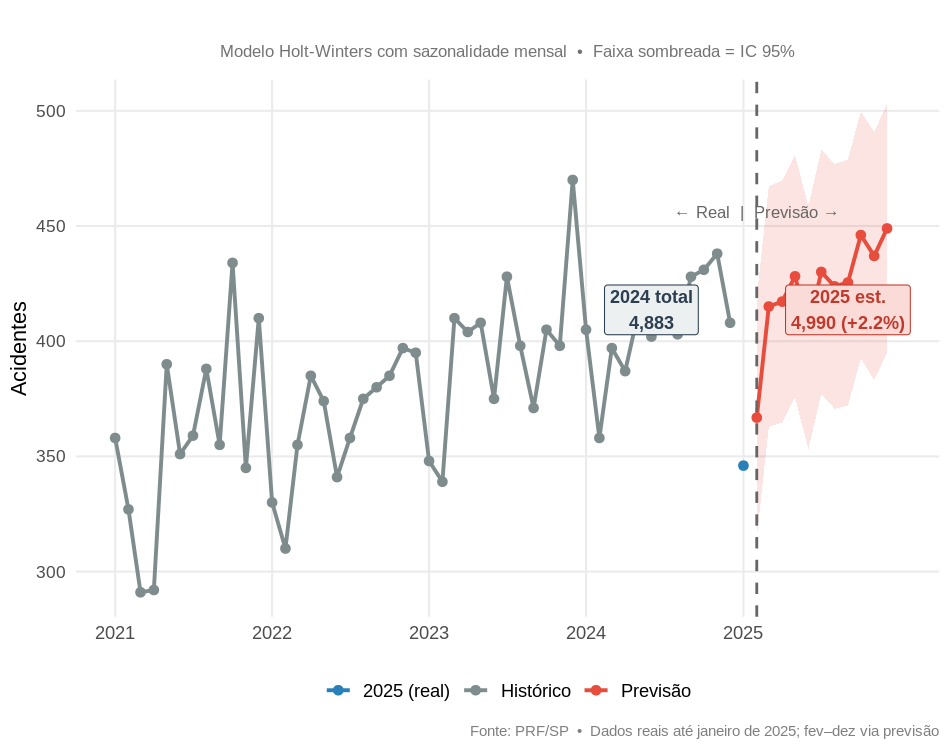

In [ ]:
%%R -w 950 -h 750 -r 120

library(tidyverse)

# ================================================================
# PREVISÃO 2025 — HOLT-WINTERS (base R, sem pacotes extras)
# ================================================================

df <- read_rds("/content/drive/MyDrive/PI_JP/base_prf_sp_tratada.rds")

# 1. AGREGA: acidentes por mês
df_mensal <- df %>%
  mutate(data = as.Date(data_inversa),
         ano  = as.integer(format(data, "%Y")),
         mes  = as.integer(format(data, "%m"))) %>%
  filter(!is.na(data)) %>%
  count(ano, mes, name = "acidentes") %>%
  arrange(ano, mes)

# Identifica até onde vai o dado real em 2025
ultimo_ano <- max(df_mensal$ano)
ultimo_mes <- max(df_mensal$mes[df_mensal$ano == ultimo_ano])

cat("Dados disponíveis até:", month.abb[ultimo_mes], ultimo_ano, "\n")

# 2. RESUMO: 2024 completo vs 2025 parcial
total_2024      <- df_mensal %>% filter(ano == 2024) %>% pull(acidentes) %>% sum()
total_2025_real <- df_mensal %>% filter(ano == 2025) %>% pull(acidentes) %>% sum()

cat("\n=== RESUMO DOS DADOS REAIS ===\n")
cat("Acidentes em 2024 (ano completo):", total_2024, "\n")
cat("Acidentes em 2025 (até", month.abb[ultimo_mes], "):", total_2025_real, "\n")

# 3. SÉRIE TEMPORAL — treina apenas com dados até 2024
df_treino    <- df_mensal %>% filter(ano < 2025)
inicio_serie <- c(min(df_treino$ano), min(df_treino$mes[df_treino$ano == min(df_treino$ano)]))

serie_ts <- ts(df_treino$acidentes,
               start     = inicio_serie,
               frequency = 12)

# 4. HOLT-WINTERS com sazonalidade
modelo_hw <- HoltWinters(serie_ts)

meses_previstos <- 12 - ultimo_mes
prev    <- predict(modelo_hw, n.ahead = meses_previstos + ultimo_mes,
                   prediction.interval = TRUE, level = 0.95)
prev_df <- as.data.frame(prev)
colnames(prev_df) <- c("fit", "lwr", "upr")

prev_futuros <- prev_df[(nrow(prev_df) - meses_previstos + 1):nrow(prev_df), ] %>%
  mutate(ano = 2025, mes = (ultimo_mes + 1):12, tipo = "Previsão")

total_2025_prev  <- sum(prev_futuros$fit)
total_2025_compl <- total_2025_real + total_2025_prev
variacao_pct     <- round((total_2025_compl - total_2024) / total_2024 * 100, 1)

cat("\n=== PREVISÃO 2025 (fev a dez) ===\n")
cat("Acidentes previstos (fev–dez 2025):", round(total_2025_prev), "\n")
cat("Total estimado 2025 (real + previsão):", round(total_2025_compl), "\n")
cat("Variação vs 2024:", variacao_pct, "%",
    ifelse(variacao_pct > 0, "▲ AUMENTO", "▼ REDUÇÃO"), "\n")

# 5. MONTA DATAFRAME UNIFICADO PARA O GRÁFICO
df_historico <- df_mensal %>%
  mutate(fit = acidentes, lwr = NA_real_, upr = NA_real_,
         tipo = ifelse(ano == 2025, "2025 (real)", "Histórico"))

df_prev_plot <- prev_futuros %>%
  select(ano, mes, fit, lwr, upr, tipo)

df_plot <- bind_rows(
  df_historico %>% select(ano, mes, fit, lwr, upr, tipo),
  df_prev_plot
) %>%
  mutate(data = as.Date(paste(ano, mes, "01", sep = "-")))

# 6. GRÁFICO
cores <- c("Histórico"   = "#7f8c8d",
           "2025 (real)" = "#2980b9",
           "Previsão"    = "#e74c3c")

# Breaks manuais: só os anos presentes nos dados (sem 2026)
breaks_anos <- seq(as.Date(paste(min(df_plot$ano), "01", "01", sep = "-")),
                   as.Date("2025-01-01"),
                   by = "1 year")

ggplot(df_plot, aes(x = data, y = fit, color = tipo)) +

  geom_ribbon(data = df_plot %>% filter(tipo == "Previsão"),
              aes(ymin = lwr, ymax = upr, fill = tipo),
              alpha = 0.15, color = NA) +
  scale_fill_manual(values = c("Previsão" = "#e74c3c"), guide = "none") +

  geom_line(linewidth = 1.1) +
  geom_point(size = 2.2) +

  geom_vline(xintercept = as.numeric(as.Date(paste("2025", ultimo_mes + 1, "01", sep = "-"))),
             linetype = "dashed", color = "gray40", linewidth = 0.8) +
  annotate("text",
           x = as.Date(paste("2025", ultimo_mes + 1, "01", sep = "-")),
           y = max(df_plot$fit, na.rm = TRUE) * 0.97,
           label = "← Real  |  Previsão →",
           size = 3.5, color = "gray40", hjust = 0.5) +

  annotate("label",
           x = as.Date("2024-06-01"), y = max(df_plot$fit, na.rm = TRUE) * 0.88,
           label = paste0("2024 total\n", format(total_2024, big.mark = ",")),
           size = 3.8, fill = "#ecf0f1", color = "#2c3e50", fontface = "bold") +
  annotate("label",
           x = as.Date("2025-09-01"), y = max(df_plot$fit, na.rm = TRUE) * 0.88,
           label = paste0("2025 est.\n", format(round(total_2025_compl), big.mark = ","),
                          " (", ifelse(variacao_pct > 0, "+", ""), variacao_pct, "%)"),
           size = 3.8, fill = ifelse(variacao_pct > 0, "#fadbd8", "#d5f5e3"),
           color = ifelse(variacao_pct > 0, "#c0392b", "#1e8449"), fontface = "bold") +

  scale_color_manual(values = cores, name = NULL) +
  scale_x_date(breaks = breaks_anos, date_labels = "%Y") +
  coord_cartesian(xlim = c(min(df_plot$data), as.Date("2025-12-31"))) +
  scale_y_continuous(labels = scales::comma_format(big.mark = ",")) +

  theme_minimal(base_size = 13) +
  labs(
    title    = "",
    subtitle = "Modelo Holt-Winters com sazonalidade mensal  •  Faixa sombreada = IC 95%",
    x = NULL, y = "Acidentes",
    caption  = "Fonte: PRF/SP  •  Dados reais até janeiro de 2025; fev–dez via previsão"
  ) +
  theme(
    plot.title       = element_text(face = "bold", size = 16, hjust = 0.5),
    plot.subtitle    = element_text(size = 10, hjust = 0.5, color = "gray45",
                                     margin = margin(b = 12)),
    plot.caption     = element_text(size = 9, color = "gray50"),
    axis.text.x      = element_text(size = 11),
    legend.position  = "bottom",
    legend.text      = element_text(size = 11),
    panel.grid.minor = element_blank()
  )

In [ ]:
%%R
# Instale o pacote se necessário: install.packages("randomForest")
library(randomForest)

# Converte colunas de texto para fatores (necessário para o Random Forest no R)
df_rf <- df_modelo %>%
  mutate_if(is.character, as.factor)

# Treina o modelo Random Forest (Regressão para a variável 'mortos')
modelo_rf <- randomForest(
  mortos ~ veiculos + hora + fim_semana + pista_simples + uso_rural +
           fase_dia + clima + tracado_via + causa_acidente,
  data = df_rf,
  ntree = 100,
  importance = TRUE
)

# Resultados e importância das variáveis
print(modelo_rf)
varImpPlot(modelo_rf, main="Importância das Variáveis - Random Forest")

Error in library(randomForest) : 
  there is no package called ‘randomForest’


RInterpreterError: Failed to parse and evaluate line '# Instale o pacote se necessário: install.packages("randomForest")\nlibrary(randomForest)\n\n# Converte colunas de texto para fatores (necessário para o Random Forest no R)\ndf_rf <- df_modelo %>%\n  mutate_if(is.character, as.factor)\n\n# Treina o modelo Random Forest (Regressão para a variável \'mortos\')\nmodelo_rf <- randomForest(\n  mortos ~ veiculos + hora + fim_semana + pista_simples + uso_rural +\n           fase_dia + clima + tracado_via + causa_acidente,\n  data = df_rf,\n  ntree = 100,\n  importance = TRUE\n)\n\n# Resultados e importância das variáveis\nprint(modelo_rf)\nvarImpPlot(modelo_rf, main="Importância das Variáveis - Random Forest")\n'.
R error message: 'Error in library(randomForest) : \n  there is no package called ‘randomForest’'